docker-compose up --build -d

RUBY COM CACHE

for U in 25 50 100; do
  echo "Testando com $U usuários..."
  locust -f locustfile.py \
    --host http://localhost:4567 \
    --users $U \
    --spawn-rate 2 \
    --run-time 60s \
    --headless \
    --csv resultados/ruby_cache_${U}u
  echo "Feito!"
done

docker-compose down

RUBY SEM CACHE

docker-compose -f docker-compose-ruby-no-cache.yml up --build -d

for U in 25 50 100; do
  locust -f locustfile.py \
    --host http://localhost:4567 \
    --users $U --spawn-rate 2 --run-time 60s --headless \
    --csv resultados/ruby_nocache_${U}u
done

docker-compose -f docker-compose-ruby-no-cache.yml down

PYTHON COM CACHE

docker-compose -f docker-compose-python.yml up --build -d

for U in 25 50 100; do
  locust -f locustfile.py \
    --host http://localhost:5000 \
    --users $U --spawn-rate 2 --run-time 60s --headless \
    --csv resultados/python_cache_${U}u
done

docker-compose -f docker-compose-python.yml down

PYTHON SEM CACHE

docker-compose -f docker-compose-python-no-cache.yml up --build -d

for U in 25 50 100; do
  locust -f locustfile.py \
    --host http://localhost:5000 \
    --users $U --spawn-rate 2 --run-time 60s --headless \
    --csv resultados/python_nocache_${U}u
done

docker-compose -f docker-compose-python-no-cache.yml down

In [10]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# Configurações visuais dos gráficos
%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,          # qualidade da imagem
    'font.size': 11,
    'axes.grid': True,          # linhas de grade
    'grid.alpha': 0.4,
    'axes.spines.top': False,   # remove borda superior
    'axes.spines.right': False, # remove borda direita
})

print('Bibliotecas importadas com sucesso!')
print('Versão pandas:', pd.__version__)
print('Versão numpy:', np.__version__)


Bibliotecas importadas com sucesso!
Versão pandas: 3.0.3
Versão numpy: 2.4.4


In [11]:
def carregar_resultados_reais(pasta='resultados'):
    """
    Lê os CSVs gerados pelo Locust e monta um DataFrame.
    Formato esperado do nome do arquivo:
        ruby_cache_10u_stats.csv
        python_nocache_25u_stats.csv
        etc.
    """
    import glob

    mapa_nomes = {
        'ruby_cache':       'Ruby + Cache',
        'ruby_nocache':     'Ruby + Sem Cache',
        'python_cache':     'Python + Cache',
        'python_nocache':   'Python + Sem Cache',
    }

    arquivos = sorted(glob.glob(os.path.join(pasta, '*_stats.csv')))

    if not arquivos:
        print(f'Nenhum arquivo _stats.csv encontrado em {pasta}/')
        print('Rode os testes primeiro (Módulo 7) e volte aqui.')
        return None

    linhas = []
    for arq in arquivos:
        nome = os.path.basename(arq).replace('_stats.csv', '')  # ex: ruby_cache_10u
        partes = nome.rsplit('_', 1)                             # ['ruby_cache', '10u']
        prefixo = partes[0]
        usuarios = int(partes[1].replace('u', '')) if len(partes) == 2 else 0
        cenario = mapa_nomes.get(prefixo, prefixo)

        df_csv = pd.read_csv(arq)
        
        # Pega só a linha de totais
        
        agg = df_csv[df_csv['Name'] == 'Aggregated'].iloc[0]
        total_reqs = agg.get('Request Count', 0)
        falhas = agg.get('Failure Count', 0)
        # Calcula a taxa (evitando divisão por zero)
        taxa_erro = (falhas / total_reqs * 100) if total_reqs > 0 else 0

        linhas.append({
            'cenario':    cenario,
            'usuarios':   usuarios,
            'mediana_ms': agg.get('50%',   agg.get('Median Response Time', 0)),
            'p95_ms':     agg.get('95%',   0),
            'total_reqs': total_reqs,
            'taxa_erro': taxa_erro,
            'p99_ms':     agg.get('99%',   0),
            'media_ms':   agg.get('Average Response Time', 0),
            'rps':        agg.get('Requests/s', 0),
            'falhas':     agg.get('Failure Count', 0),
        })

    df_real = pd.DataFrame(linhas).sort_values(['cenario', 'usuarios'])
    print(f'{len(df_real)} testes carregados!')
    return df_real


# Tenta carregar resultados reais
import glob
csvs_existentes = glob.glob('resultados/*_stats.csv')

if csvs_existentes:
    print(f'Encontrados {len(csvs_existentes)} arquivo(s) de resultado!')
    df_real = carregar_resultados_reais()
    if df_real is not None:
        print()
        print(df_real.to_string(index=False))
else:
    print('Ainda sem resultados reais — usando dados simulados nas análises acima.')
    print()
    print('Quando tiver resultados:')
    print('  1. Execute os comandos do Módulo 7 no terminal')
    print('  2. Volte aqui e execute: df_real = carregar_resultados_reais()')
    print('  3. Use df_real nos gráficos no lugar de medianas/p95/rps')


Encontrados 12 arquivo(s) de resultado!
12 testes carregados!

           cenario  usuarios  mediana_ms  p95_ms  total_reqs  taxa_erro  p99_ms    media_ms        rps  falhas
    Python + Cache        25           8      22        6149   0.113840    4100   96.370136 103.640860       7
    Python + Cache        50          18     110       14394  26.865361     140   37.419169 245.345487    3867
    Python + Cache       100          65     300       15820  27.597977     680   95.072956 265.604650    4366
Python + Sem Cache        25        4600    9800         271   0.000000   11000 4629.404704   4.599798       0
Python + Sem Cache        50        7500   18000         255   2.745098   24000 7522.498568   4.317853       7
Python + Sem Cache       100        7400   22000         238   0.000000   31000 9669.870090   4.017814       0
      Ruby + Cache        25          26      89        6674   0.164819    1600   76.201637 112.461913      11
      Ruby + Cache        50          46     240 

---
# Gráficos com Resultados Reais

Execute as células abaixo **depois** de `df_real` estar carregado acima.

In [12]:
import glob

# Recarrega resultados (útil se novos CSVs foram gerados)
df_real = carregar_resultados_reais()

if df_real is not None:
    print(df_real.to_string(index=False))


12 testes carregados!
           cenario  usuarios  mediana_ms  p95_ms  total_reqs  taxa_erro  p99_ms    media_ms        rps  falhas
    Python + Cache        25           8      22        6149   0.113840    4100   96.370136 103.640860       7
    Python + Cache        50          18     110       14394  26.865361     140   37.419169 245.345487    3867
    Python + Cache       100          65     300       15820  27.597977     680   95.072956 265.604650    4366
Python + Sem Cache        25        4600    9800         271   0.000000   11000 4629.404704   4.599798       0
Python + Sem Cache        50        7500   18000         255   2.745098   24000 7522.498568   4.317853       7
Python + Sem Cache       100        7400   22000         238   0.000000   31000 9669.870090   4.017814       0
      Ruby + Cache        25          26      89        6674   0.164819    1600   76.201637 112.461913      11
      Ruby + Cache        50          46     240       11830   0.000000     400   77.09346

In [13]:
if df_real is None:
    raise SystemExit("Sem dados. Execute os testes primeiro.")

os.makedirs('resultados', exist_ok=True)

CORES = {
    'Ruby + Cache':       '#1565C0',
    'Ruby + Sem Cache':   '#E53935',
    'Python + Cache':     '#2E7D32',
    'Python + Sem Cache': '#F57F17',
}

cargas   = sorted(df_real['usuarios'].unique())
cenarios = sorted(df_real['cenario'].unique())
print('Cenários disponíveis:', cenarios)
print('Cargas disponíveis:  ', cargas)


def grafico_barras_por_carga(
    df,
    coluna,
    titulo,
    ylabel,
    arquivo_saida,
    formato_rotulo=None,
    linha_referencia=None,
    legenda_linha=None,
    ylim_bottom=0,
):
    x = np.arange(len(cargas))
    largura = 0.8 / max(len(cenarios), 1)

    fig, ax = plt.subplots(figsize=(11, 5.5))

    for i, cenario in enumerate(cenarios):
        sub = (
            df[df['cenario'] == cenario]
            .set_index('usuarios')
            .reindex(cargas)
        )

        valores = sub[coluna].fillna(0).to_numpy()
        deslocamento = (i - (len(cenarios) - 1) / 2) * largura

        barras = ax.bar(
            x + deslocamento,
            valores,
            width=largura,
            label=cenario,
            color=CORES.get(cenario, '#333'),
            edgecolor='white',
            linewidth=0.8,
        )

        for barra, valor in zip(barras, valores):
            if valor > 0:
                texto = formato_rotulo(valor) if formato_rotulo else f'{valor:.0f}'
                ax.text(
                    barra.get_x() + barra.get_width() / 2,
                    barra.get_height(),
                    texto,
                    ha='center',
                    va='bottom',
                    fontsize=7.5,
                    rotation=0,
                )

    if linha_referencia is not None:
        ax.axhline(
            linha_referencia,
            color='gray',
            linestyle='--',
            linewidth=1,
            alpha=0.6,
            label=legenda_linha,
        )

    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_xlabel('Usuários Virtuais Simultâneos')
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(cargas)
    ax.set_ylim(bottom=ylim_bottom)
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(arquivo_saida, bbox_inches='tight')
    plt.show()


Cenários disponíveis: ['Python + Cache', 'Python + Sem Cache', 'Ruby + Cache', 'Ruby + Sem Cache']
Cargas disponíveis:   [np.int64(25), np.int64(50), np.int64(100)]


## Gráfico 1 — Mediana do Tempo de Resposta vs Usuários

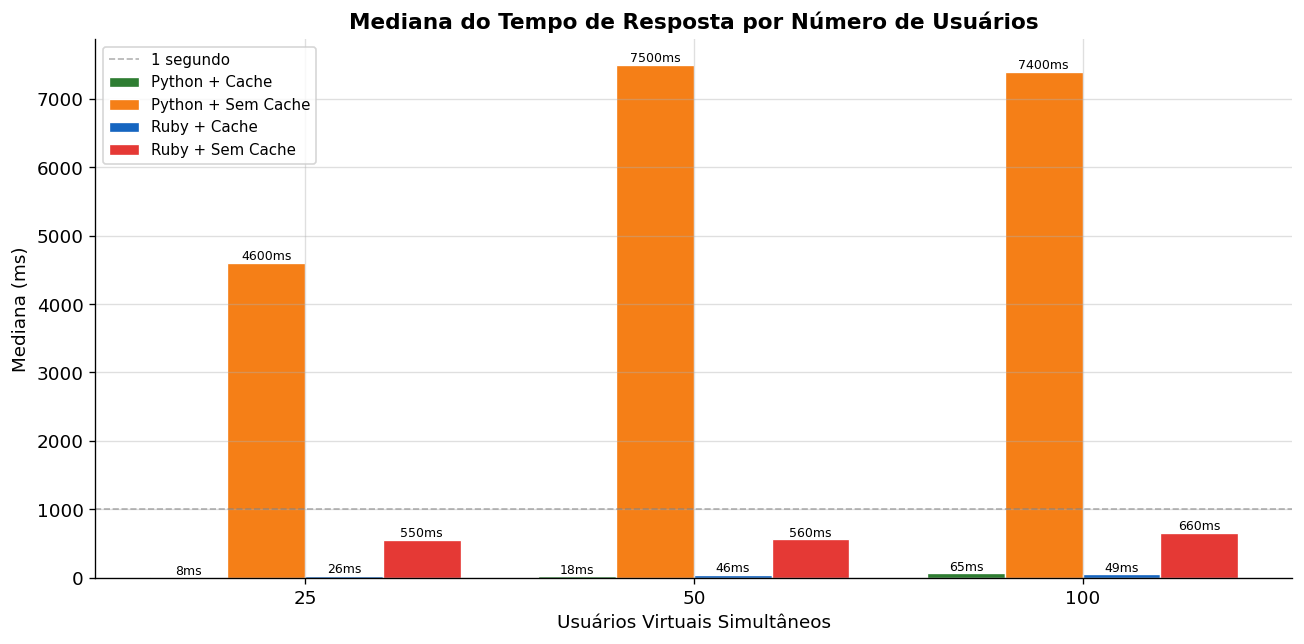

In [14]:
grafico_barras_por_carga(
    df=df_real,
    coluna='mediana_ms',
    titulo='Mediana do Tempo de Resposta por Número de Usuários',
    ylabel='Mediana (ms)',
    arquivo_saida='resultados/real_grafico1_mediana.png',
    formato_rotulo=lambda v: f'{int(v)}ms',
    linha_referencia=1000,
    legenda_linha='1 segundo',
)


## Gráfico 2 — Percentil 95 vs Usuários

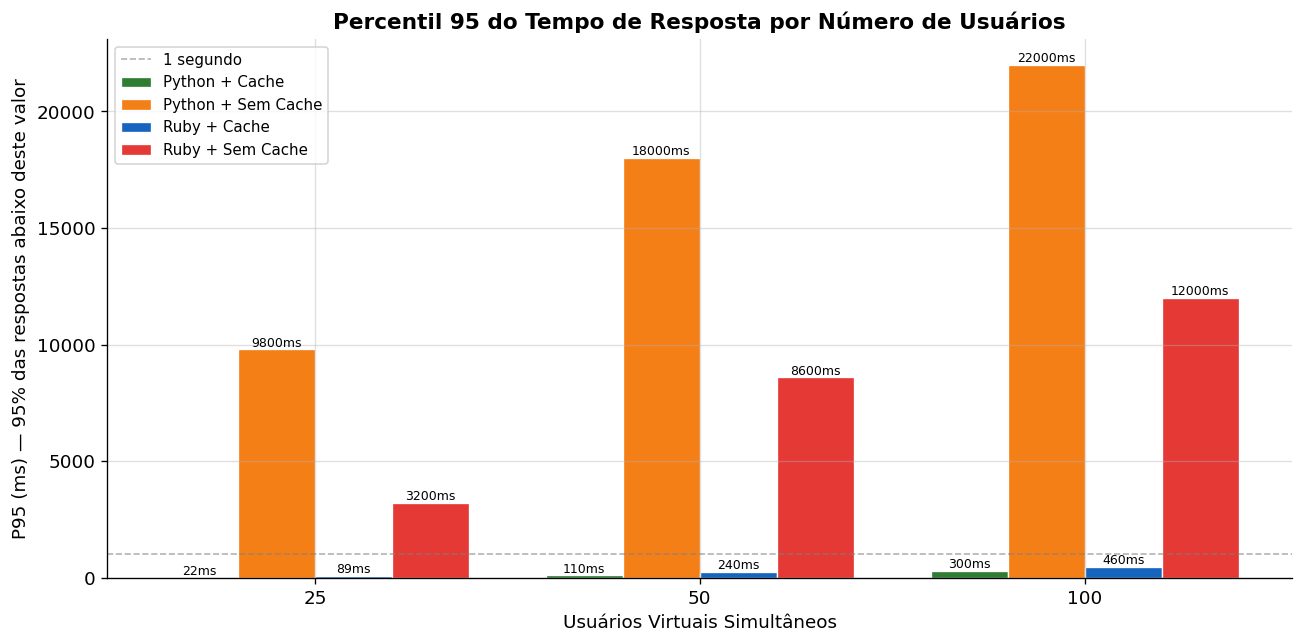

In [15]:
grafico_barras_por_carga(
    df=df_real,
    coluna='p95_ms',
    titulo='Percentil 95 do Tempo de Resposta por Número de Usuários',
    ylabel='P95 (ms) — 95% das respostas abaixo deste valor',
    arquivo_saida='resultados/real_grafico2_p95.png',
    formato_rotulo=lambda v: f'{int(v)}ms',
    linha_referencia=1000,
    legenda_linha='1 segundo',
)


## Gráfico 3 — Throughput (Requisições por Segundo)

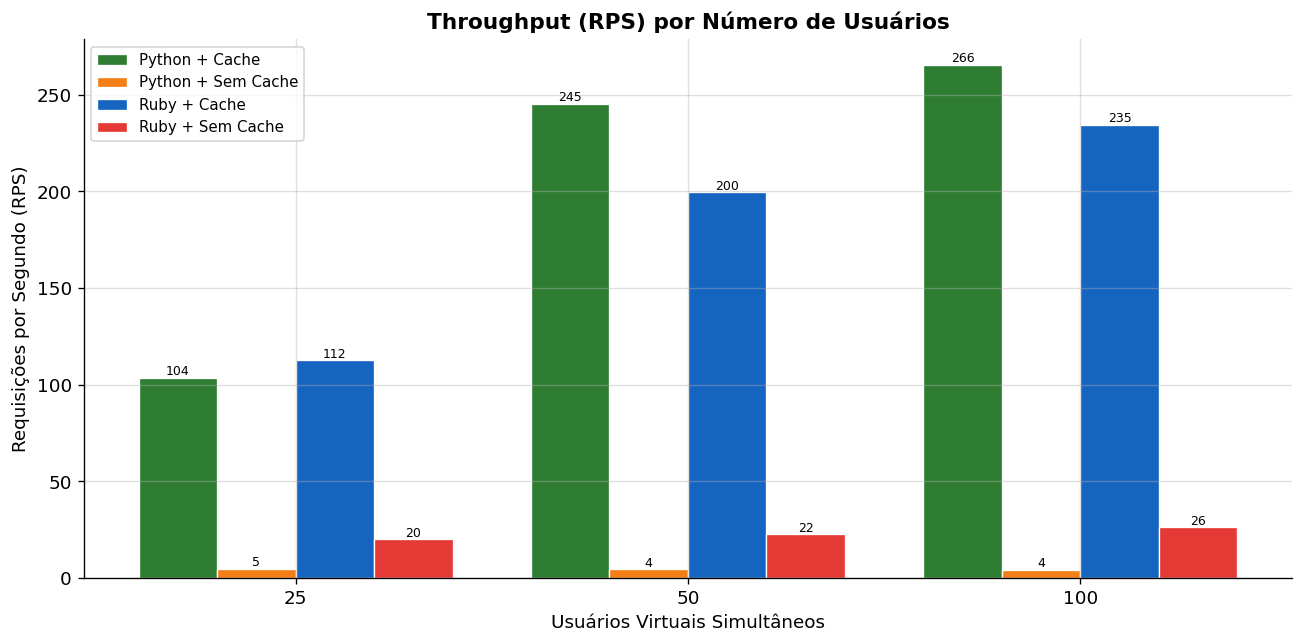

In [16]:
grafico_barras_por_carga(
    df=df_real,
    coluna='rps',
    titulo='Throughput (RPS) por Número de Usuários',
    ylabel='Requisições por Segundo (RPS)',
    arquivo_saida='resultados/real_grafico3_rps.png',
    formato_rotulo=lambda v: f'{v:.0f}',
)


## Gráfico 4 — P50 / P95 / P99 por Cenário (carga máxima)

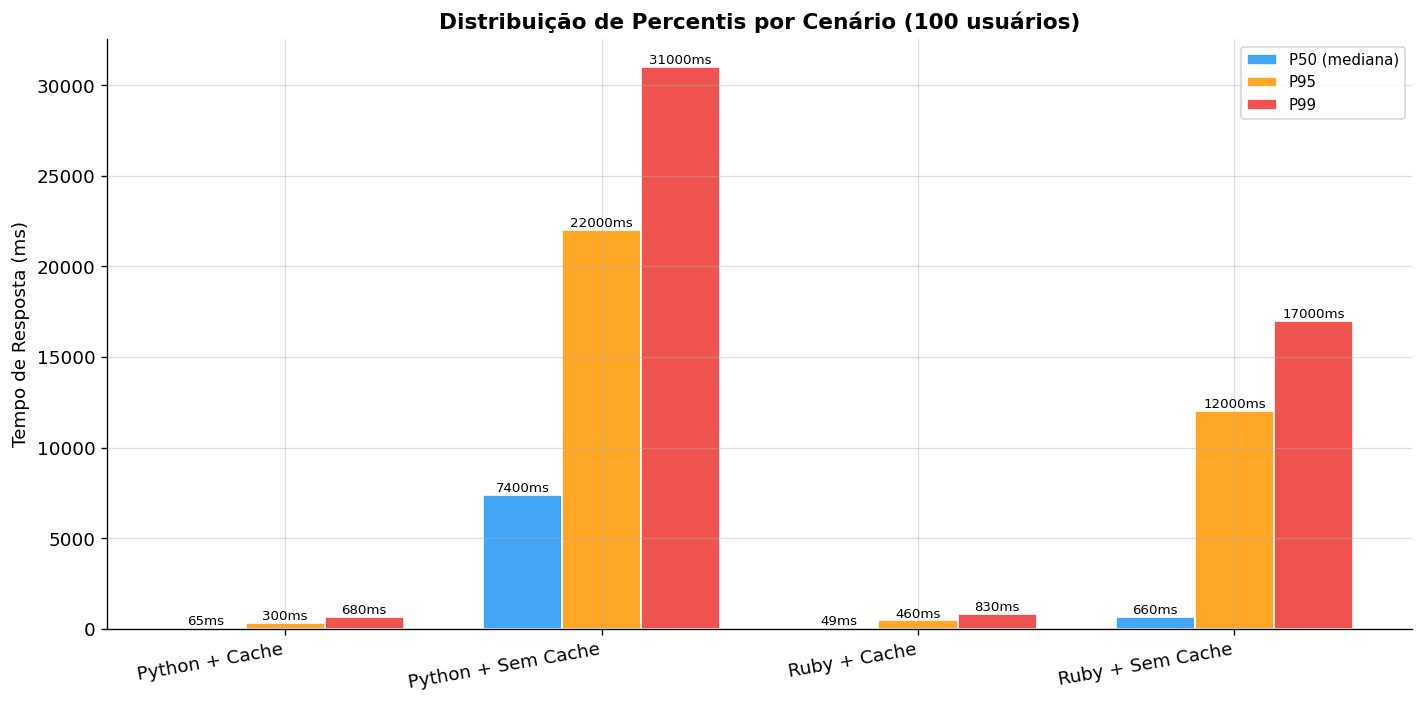

In [17]:
carga_max = max(cargas)
df_max = df_real[df_real['usuarios'] == carga_max]

x = np.arange(len(cenarios))
largura = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

p50_vals = [df_max[df_max['cenario'] == c]['mediana_ms'].values[0]
            if len(df_max[df_max['cenario'] == c]) else 0 for c in cenarios]
p95_vals = [df_max[df_max['cenario'] == c]['p95_ms'].values[0]
            if len(df_max[df_max['cenario'] == c]) else 0 for c in cenarios]
p99_vals = [df_max[df_max['cenario'] == c]['p99_ms'].values[0]
            if len(df_max[df_max['cenario'] == c]) else 0 for c in cenarios]

b50 = ax.bar(x - largura, p50_vals, largura, label='P50 (mediana)', color='#42A5F5', edgecolor='white')
b95 = ax.bar(x,           p95_vals, largura, label='P95',           color='#FFA726', edgecolor='white')
b99 = ax.bar(x + largura, p99_vals, largura, label='P99',           color='#EF5350', edgecolor='white')

for bars in [b50, b95, b99]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 20,
                    f'{int(h)}ms', ha='center', va='bottom', fontsize=8)

ax.set_title(f'Distribuição de Percentis por Cenário ({carga_max} usuários)', fontsize=13, fontweight='bold')
ax.set_ylabel('Tempo de Resposta (ms)')
ax.set_xticks(x)
ax.set_xticklabels(cenarios, rotation=10, ha='right')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('resultados/real_grafico4_percentis.png', bbox_inches='tight')
plt.show()


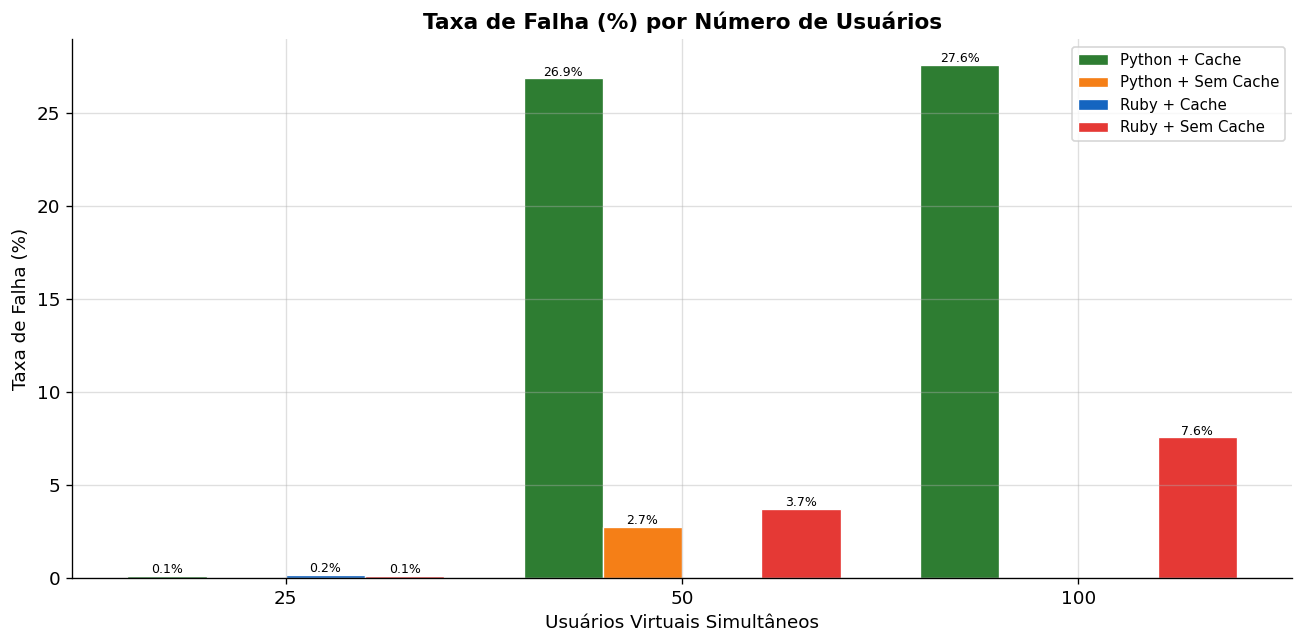

In [18]:
grafico_barras_por_carga(
    df=df_real,
    coluna='taxa_erro',
    titulo='Taxa de Falha (%) por Número de Usuários',
    ylabel='Taxa de Falha (%)',
    arquivo_saida='resultados/real_grafico5_taxa_falha.png',
    formato_rotulo=lambda v: f'{v:.1f}%',
)


In [19]:
import requests
from bs4 import BeautifulSoup

TEST_URLS = [

    "https://en.wikipedia.org/wiki/Special:AllPages",

    "https://httpbin.org/links/1000/1",
    "https://crawler-test.com",
    
    "https://github.com/apache",
    "https://arxiv.org/list/cs/recent",

    "https://linuxtracker.org/",
    "https://wordpress.org/plugins/",


    "https://news.ycombinator.com/news?p=1",

    "https://en.wikipedia.org/wiki/Index_of_computing_articles",

    "https://www.iana.org/domains/reserved"
]

print("Contando links...")
print("-" * 50)

for url in TEST_URLS:
    try:
        # Fazemos a requisição com um User-Agent para evitar bloqueios simples
        headers = {'User-Agent': 'Mozilla/5.0'}
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status() # Verifica se deu erro HTTP (ex: 404, 500)
        
        # Faz o parser do HTML
        soup = BeautifulSoup(response.text, 'html.parser')
        
        # Encontra todas as tags <a>
        links = soup.find_all('a')
        
        print(f"✅ {len(links):>4} links | {url}")
        
    except requests.exceptions.RequestException as e:
        print(f"❌ Erro ao acessar {url}: {e}")

print("-" * 50)
print("Fim da verificação.")

Contando links...
--------------------------------------------------
✅  393 links | https://en.wikipedia.org/wiki/Special:AllPages
✅  199 links | https://httpbin.org/links/1000/1
✅  415 links | https://crawler-test.com
✅  215 links | https://github.com/apache
✅  635 links | https://arxiv.org/list/cs/recent
✅  262 links | https://linuxtracker.org/
✅  101 links | https://wordpress.org/plugins/
✅  226 links | https://news.ycombinator.com/news?p=1
✅  825 links | https://en.wikipedia.org/wiki/Index_of_computing_articles
✅   65 links | https://www.iana.org/domains/reserved
--------------------------------------------------
Fim da verificação.


## Tabela Resumo Final

In [20]:
df_resumo = (
    df_real[df_real['usuarios'] == carga_max]
    .set_index('cenario')[['mediana_ms', 'p95_ms', 'p99_ms', 'rps', 'falhas', 'taxa_erro']]
    .rename(columns={
        'mediana_ms': 'Mediana (ms)',
        'p95_ms':     'P95 (ms)',
        'p99_ms':     'P99 (ms)',
        'rps':        'RPS',
        'falhas':     'Falhas',
        'taxa_erro':  'Taxa de Falha (%)',
    })
)

df_resumo['Taxa de Falha (%)'] = df_resumo['Taxa de Falha (%)'].round(2)

pior = df_resumo['Mediana (ms)'].max()
df_resumo['Speedup'] = (pior / df_resumo['Mediana (ms)']).round(1).astype(str) + 'x'

print('=' * 70)
print(f'  RESUMO — {carga_max} Usuários Virtuais Simultâneos')
print('=' * 70)
print(df_resumo.to_string())
print()
print('Gráficos salvos:')
for f in sorted(glob.glob('resultados/real_grafico*.png')):
    print(f'  {f}')


  RESUMO — 100 Usuários Virtuais Simultâneos
                    Mediana (ms)  P95 (ms)  P99 (ms)         RPS  Falhas  Taxa de Falha (%) Speedup
cenario                                                                                            
Python + Cache                65       300       680  265.604650    4366              27.60  113.8x
Python + Sem Cache          7400     22000     31000    4.017814       0               0.00    1.0x
Ruby + Cache                  49       460       830  234.641124       0               0.00  151.0x
Ruby + Sem Cache             660     12000     17000   26.066565     117               7.56   11.2x

Gráficos salvos:
  resultados\real_grafico1_mediana.png
  resultados\real_grafico2_p95.png
  resultados\real_grafico3_rps.png
  resultados\real_grafico4_percentis.png
  resultados\real_grafico5_taxa_falha.png
